In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('default')
plt.style.use(['science', 'ieee'])

In [4]:
n_center = [
    'diode-n/Diode N Center Gap 30.DAT',
    'diode-n/Diode N Center Gap 50.DAT',
    'diode-n/Diode N Center Gap 100.DAT',
]

p_center = [
    'diode-p/Diode P Center Gap 30.DAT',
    'diode-p/Diode P Center Gap 50.DAT',
    'diode-p/Diode P Center Gap 100.DAT',
]

for i, file in enumerate(n_center):
    if i == 0:
        diode = np.genfromtxt(file, skip_header=28, skip_footer=5, dtype=float, delimiter=',')
        diode = np.expand_dims(diode, axis=0)
    else:
        diode = np.vstack((diode, np.expand_dims(np.genfromtxt(file, skip_header=28, skip_footer=5, dtype=float, delimiter=','), axis=0)))

In [ ]:
gaps = [30, 50, 100]

plt.figure(figsize=(4,3))
for i in range(len(gaps)):
    plt.plot(diode[i, :, 0], diode[i, :, 1]*1e6, label=f'{gaps[i]}$\mu$m')
plt.xlabel('Voltage (V)')
plt.ylabel('Current ($\mu$A)')
plt.title('N$^+$ Center Diode I-V Characteristics')
legend = plt.legend(title='Gap Size', fontsize='small', frameon=True, fancybox=False, edgecolor='black', borderaxespad=1)
legend.get_frame().set_linewidth(0.5)
plt.savefig('diode-n-center.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
mosfets = [
    'mosfet/MOSFET 10x10 v2.DAT',
    'mosfet/MOSFET 10x100 v2.DAT',
    'mosfet/MOSFET 100x10.DAT',
    'mosfet/MOSFET 100x100.DAT',
]

labels = [
    '10x10',
    '10x100',
    '100x10',
    '100x100',
]

for i, file in enumerate(mosfets):
    if i == 0:
        mosfet = np.genfromtxt(file, skip_header=1, skip_footer=0, dtype=float, delimiter=',')
        mosfet = np.expand_dims(mosfet, axis=0)
    else:
        mosfet = np.vstack((mosfet, np.expand_dims(np.genfromtxt(file, skip_header=1, skip_footer=0, dtype=float, delimiter=','), axis=0)))

In [ ]:
# plot each sweep... skip first test batch, then plot the rest. find start and stop indices by looking at the last index
start_idx = np.argwhere(np.logical_not(np.isnan(mosfet[:,:,-1])))

for j in range(len(labels)):
    plt.figure(figsize=(4,3))
    for i in range(6):
        plt.plot(mosfet[j, start_idx[i+1,1]:start_idx[i+2,1], 0], mosfet[j, start_idx[i+1,1]:start_idx[i+2,1], 1]*1e6, label=f'{i+1}')
    plt.xlabel(f'$V_{{DS}}$ (V)')
    plt.ylabel(f'$I_{{D}}$ ($\mu$A)')
    plt.title(f'MOSFET {labels[j]} I-V Characteristics')
    legend = plt.legend(title='$V_{GS}$ (V)', fontsize='small', frameon=True, fancybox=False, edgecolor='black', borderaxespad=1)
    legend.get_frame().set_linewidth(0.5)
    plt.savefig(f'mosfet-{labels[j]}.png', dpi=300, bbox_inches='tight')
    # plt.show()

In [4]:
mosfets = [
    'good-mosfet/MOSFET 10x10.DAT',
    'good-mosfet/MOSFET 10x100.DAT',
    'good-mosfet/MOSFET 100x10.DAT',
    'good-mosfet/MOSFET 100x100.DAT',
]

labels = [
    '10x10',
    '10x100',
    '100x10',
    '100x100',
]

for i, file in enumerate(mosfets):
    if i == 0:
        mosfet = np.genfromtxt(file, skip_header=1, skip_footer=0, dtype=float, delimiter=',')
        mosfet = np.expand_dims(mosfet, axis=0)
    else:
        mosfet = np.vstack((mosfet, np.expand_dims(np.genfromtxt(file, skip_header=1, skip_footer=0, dtype=float, delimiter=','), axis=0)))

In [ ]:
# plot each sweep... skip first test batch, then plot the rest. find start and stop indices by looking at the last index
start_idx = np.argwhere(np.logical_not(np.isnan(mosfet[:,:,-1])))

for j in range(len(labels)):
    plt.figure(figsize=(4,3))
    for i in range(6):
        plt.plot(mosfet[j, start_idx[i+1,1]:start_idx[i+2,1], 0], mosfet[j, start_idx[i+1,1]:start_idx[i+2,1], 1]*1e6, label=f'{i+1}')
    plt.xlabel(f'$V_{{DS}}$ (V)')
    plt.ylabel(f'$I_{{D}}$ ($\mu$A)')
    plt.title(f'MOSFET {labels[j]} I-V Characteristics')
    legend = plt.legend(title='$V_{GS}$ (V)', fontsize='small', frameon=True, fancybox=False, edgecolor='black', borderaxespad=1)
    legend.get_frame().set_linewidth(0.5)
    plt.savefig(f'good-mosfet-{labels[j]}.png', dpi=300, bbox_inches='tight')
    # plt.show()

In [2]:
# tlm
tlm_files = [
    'tlm/TLM 50.DAT',
    'tlm/TLM 100.DAT',
    'tlm/TLM 200.DAT',
    'tlm/TLM 400.DAT',
    'tlm/TLM 800.DAT',
    'tlm/TLM 1600.DAT',
]

labels = [
    50,
    100,
    200,
    400,
    800,
    1600,
]

for i, file in enumerate(tlm_files):
    if i == 0:
        tlm = np.genfromtxt(file, skip_header=28, skip_footer=5, dtype=float, delimiter=',')
        tlm = np.expand_dims(tlm, axis=0)
    else:
        tlm = np.vstack((tlm, np.expand_dims(np.genfromtxt(file, skip_header=28, skip_footer=5, dtype=float, delimiter=','), axis=0)))

In [3]:
def increasing_segment(arr : np.ndarray) -> tuple[int, int]:
    mask = np.diff(arr, prepend=arr[0]) > 0
    # get longest connected segment of true values
    start_stops = []
    for i in range(1, len(mask)):
        if mask[i] and not mask[i-1]:
            start = i
        elif not mask[i] and mask[i-1]:
            end = i
            start_stops.append((start, end))
    if len(start_stops) == 0:
        return (0, len(arr))
    start_stop = max(start_stops, key=lambda x: x[1] - x[0])
    return start_stop

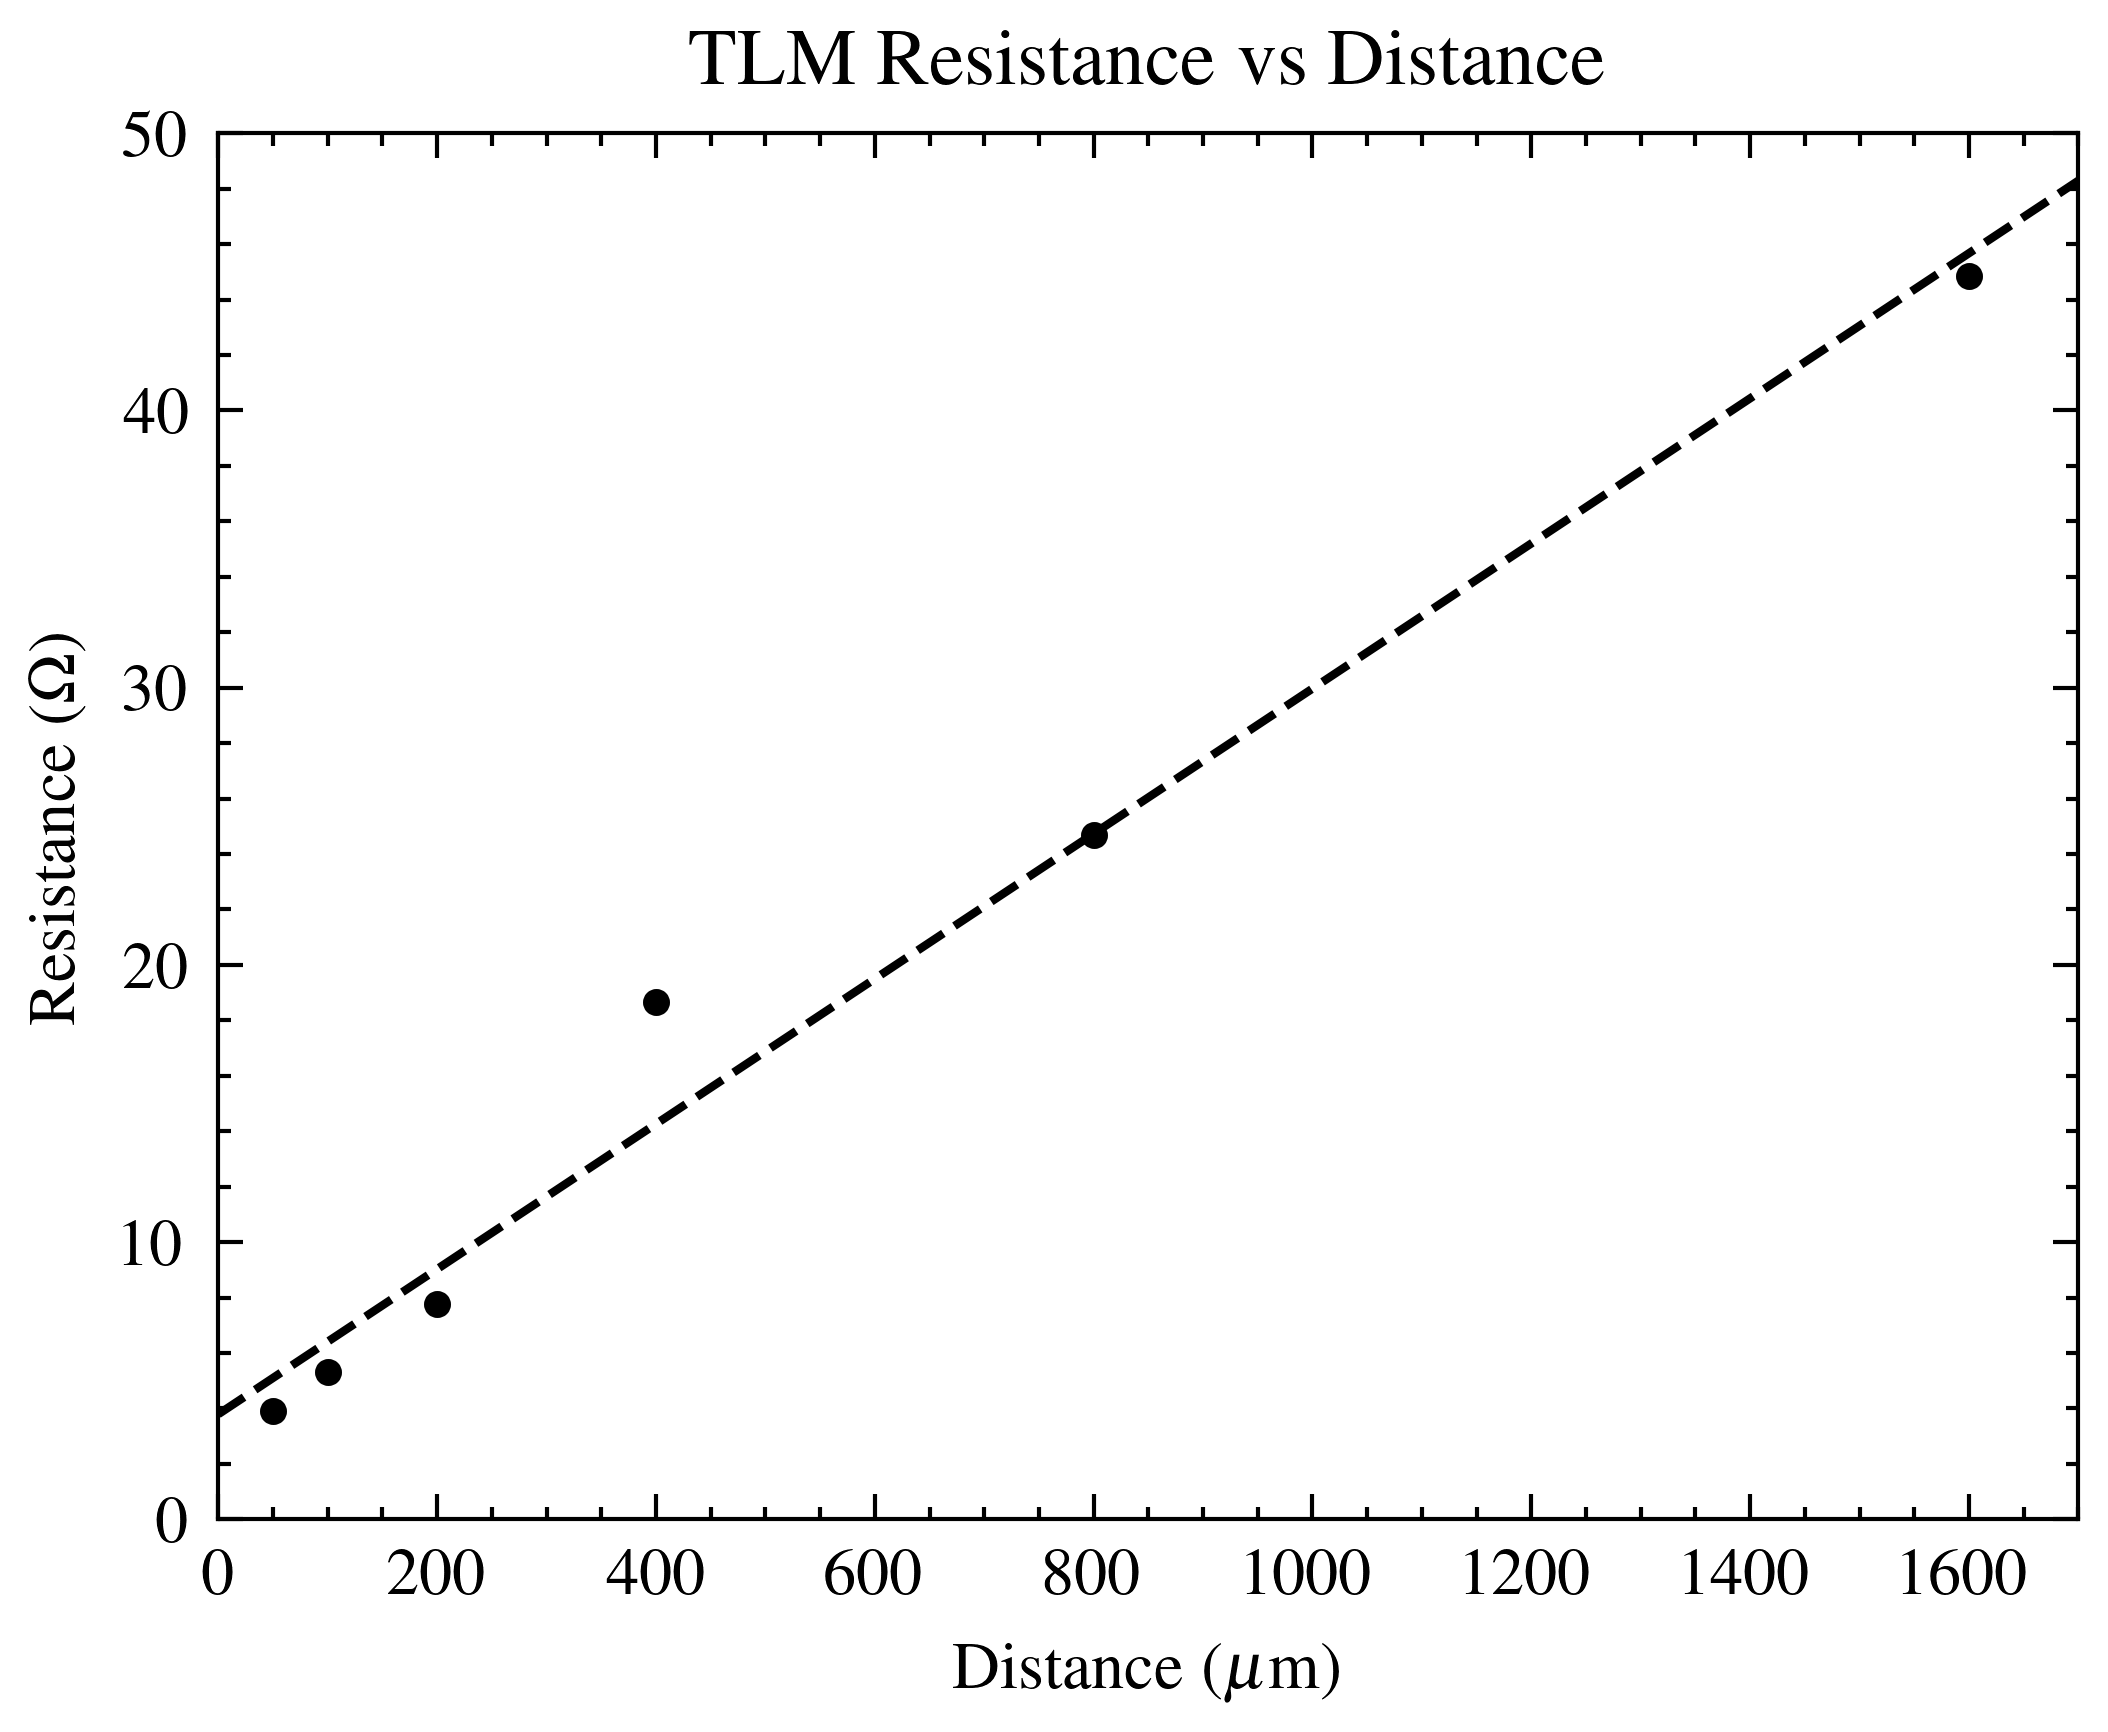

In [4]:
# find the resistance for each tlm, then plot the resistance vs distance
resistances = []
for i in range(len(labels)):
    # just take the area where current is increasing
    start, stop = increasing_segment(tlm[i, :, 1])
    resistance = np.mean(tlm[i, start:stop, 0] / tlm[i, start:stop, 1])
    resistances.append(resistance)

# estimate contact resistance by finding line of best fit and finding y-intercept
best_fit = np.polynomial.Polynomial.fit(
    np.array(labels, dtype=float),
    np.array(resistances, dtype=float),
    deg=1
)

contact_resistance = best_fit(0) / 2
sheet_resistance = best_fit.convert().coef[1] * 100

line_x = [x for x in range(0, 1800, 10)]
line_y = best_fit(line_x)

plt.figure(figsize=(4,3))
plt.scatter(labels, resistances, s=5, label='Mean Resistance')
plt.plot(line_x, line_y, linestyle='--', label='Line of Best Fit')
plt.xlim(0, 1700)
plt.ylim(0, 50)
plt.xlabel('Distance ($\mu$m)')
plt.ylabel('Resistance ($\Omega$)')
plt.title('TLM Resistance vs Distance')
# plt.savefig('good-tlm-resistance.png', dpi=300, bbox_inches='tight')
plt.show()